 In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will
seek to predict Sales using regression trees and related approaches,
treating the response as a quantitative variable.

(a) Split the data set into a training set and a test set.

In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv"
carseats = pd.read_csv(url)

carseats.head()


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
from sklearn.tree import DecisionTreeRegressor, plot_tree
import numpy as np
import matplotlib.pyplot as plt

carseats_dummies = pd.get_dummies(carseats, drop_first=True)

X = carseats_dummies.drop('Sales', axis=1)
y = carseats_dummies['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Number of training set samples: {len(X_train)}")
print(f"Number of test set samples: {len(X_test)}")

Number of training set samples: 280
Number of test set samples: 120


(b) Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?


(b) Testing of unpruned regression trees MSE: 4.805


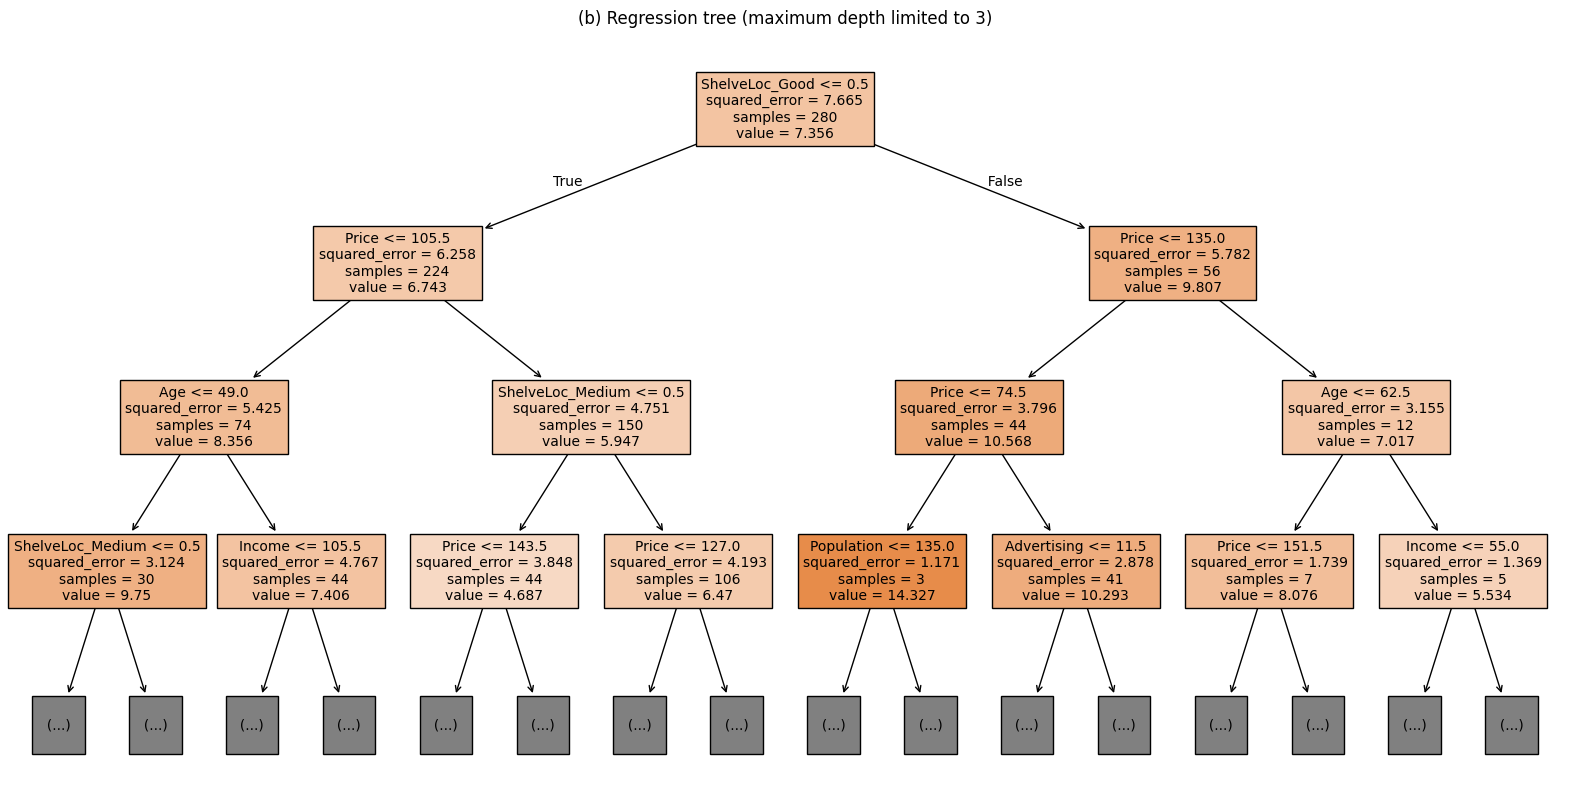

In [15]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
test_mse_tree = MSE(y_test, y_pred_tree)
print(f"\n(b) Testing of unpruned regression trees MSE: {test_mse_tree:.3f}")

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns.tolist(),
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title("(b) Regression tree (maximum depth limited to 3)")
plt.show()

(c) Use cross-validation in order to determine the optimal level of
tree complexity. Does pruning the tree improve the test MSE?

In [16]:
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

from sklearn.model_selection import GridSearchCV

tree_base = DecisionTreeRegressor(random_state=42)

param_grid = {'ccp_alpha': ccp_alphas[ccp_alphas > 0]}
grid_search = GridSearchCV(
    estimator=tree_base,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['ccp_alpha']
print(f"\n(c) The best was found through 5-fold cross-validation. ccp_alpha: {best_alpha:.4f}")

pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)

y_pred_pruned = pruned_tree.predict(X_test)
test_mse_pruned = MSE(y_test, y_pred_pruned)
print(f"(c) Testing of the regressed tree after pruning MSE: {test_mse_pruned:.3f}")

improvement = "是" if test_mse_pruned < test_mse_tree else "否"
print(f"Did pruning improve the test of MSE ({test_mse_pruned:.3f} < {test_mse_tree:.3f}): {improvement}")


(c) The best was found through 5-fold cross-validation. ccp_alpha: 0.0351
(c) Testing of the regressed tree after pruning MSE: 4.395
Did pruning improve the test of MSE (4.395 < 4.805): 是


(d) Use the bagging approach in order to analyze this data. What
test MSE do you obtain? Use the feature_importance_ values to
determine which variables are most important.

In [17]:
from sklearn.ensemble import BaggingRegressor

bagging = BaggingRegressor(
    DecisionTreeRegressor(random_state=42),
    n_estimators=500,
    max_samples=1.0,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)
test_mse_bagging = MSE(y_test, y_pred_bagging)
print(f"\n(d) Testing the Bagging Model (MSE): {test_mse_bagging:.3f}")

from sklearn.inspection import permutation_importance

r_bagging = permutation_importance(
    bagging, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
sorted_idx = r_bagging.importances_mean.argsort()[::-1]

print("\n(d) Bagging model: Permutation Importance (variable importance):")
for i in sorted_idx:
    print(f"  {X.columns[i]:<15}: {r_bagging.importances_mean[i]:.4f}")


(d) Testing the Bagging Model (MSE): 2.464

(d) Bagging model: Permutation Importance (variable importance):
  ShelveLoc_Good : 0.6120
  Price          : 0.5049
  CompPrice      : 0.1435
  Age            : 0.0939
  ShelveLoc_Medium: 0.0816
  Advertising    : 0.0775
  Income         : 0.0318
  Education      : 0.0014
  Population     : 0.0013
  US_Yes         : -0.0010
  Urban_Yes      : -0.0032


(e) Use random forests to analyze this data. What test MSE do
you obtain? Use the feature_importance_ values to determine
which variables are most important. Describe the effect of m, the
number of variables considered at each split, on the error rate
obtained.

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
test_mse_rf = MSE(y_test, y_pred_rf)
print(f"\n(e) Testing the Random Forest Model of MSE (m=p/3): {test_mse_rf:.3f}")

sorted_idx_rf = rf.feature_importances_.argsort()[::-1]

print("\n(e) Random forest model feature_importances_ (variable importance):")
for i in sorted_idx_rf:
    print(f"  {X.columns[i]:<15}: {rf.feature_importances_[i]:.4f}")

p = X_train.shape[1]
print(f"\n(e) Description of the effect of variable m (P={p}):")
print("  * m=P (Bagging): The trees are highly correlated, and the variance decreases only slightly.")
print("  * m=P/3 (Random Forest default): The low correlation between trees typically results in the lowest overall variance and error of the model.")
print("  * m=1: The correlation between trees is the lowest, but this may lead to poor performance (high bias) of individual trees.")
print("Typically, as m increases from 1 to P, the test error will first decrease (correlation decreases), and then may increase slightly (tree correlation increases).")

oob_errors = []
m_values = [1, int(p/3), p]

for m in m_values:
    current_rf = RandomForestRegressor(
        n_estimators=500,
        max_features=m,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    current_rf.fit(X_train, y_train)
    oob_mse = MSE(y_train, current_rf.oob_prediction_)
    oob_errors.append(oob_mse)
    print(f"  m={m} (max_features): OOB MSE = {oob_mse:.3f}")



(e) Testing the Random Forest Model of MSE (m=p/3): 2.483

(e) Random forest model feature_importances_ (variable importance):
  Price          : 0.3234
  ShelveLoc_Good : 0.1920
  Age            : 0.1195
  CompPrice      : 0.1063
  Advertising    : 0.0712
  Income         : 0.0523
  ShelveLoc_Medium: 0.0509
  Population     : 0.0405
  Education      : 0.0295
  Urban_Yes      : 0.0077
  US_Yes         : 0.0066

(e) Description of the effect of variable m (P=11):
  * m=P (Bagging): The trees are highly correlated, and the variance decreases only slightly.
  * m=P/3 (Random Forest default): The low correlation between trees typically results in the lowest overall variance and error of the model.
  * m=1: The correlation between trees is the lowest, but this may lead to poor performance (high bias) of individual trees.
Typically, as m increases from 1 to P, the test error will first decrease (correlation decreases), and then may increase slightly (tree correlation increases).
  m=1 (max_

(f) Now analyze the data using BART, and report your results